In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import matplotlib_style
from helpers import rename_patient

In [54]:
# Paths
# on server:

# local:
in_path = Path('~/thesis_files/statistical_results/.per_patient.pkl').expanduser()
out_path = Path('~/Developer/MastersThesis/src/figures/copes_plot.pdf').expanduser()

In [21]:
comp = pd.read_pickle(in_path)

t = comp['corr_of_pred_errors'].copy()
t.index = t.index.map(rename_patient).rename('patient')
t.columns.name = None
t

,train,test
patient,,
C01,0.853414,0.880122
C02,0.808760,0.739500
C03,0.853980,0.849131
U01,0.821004,0.822417
U03,0.671090,0.561897
U04,0.514272,0.412429
U05,0.804766,0.812181
U07,0.854925,0.901007
U12,0.490606,0.345045


In [22]:
matplotlib_style.apply_style()

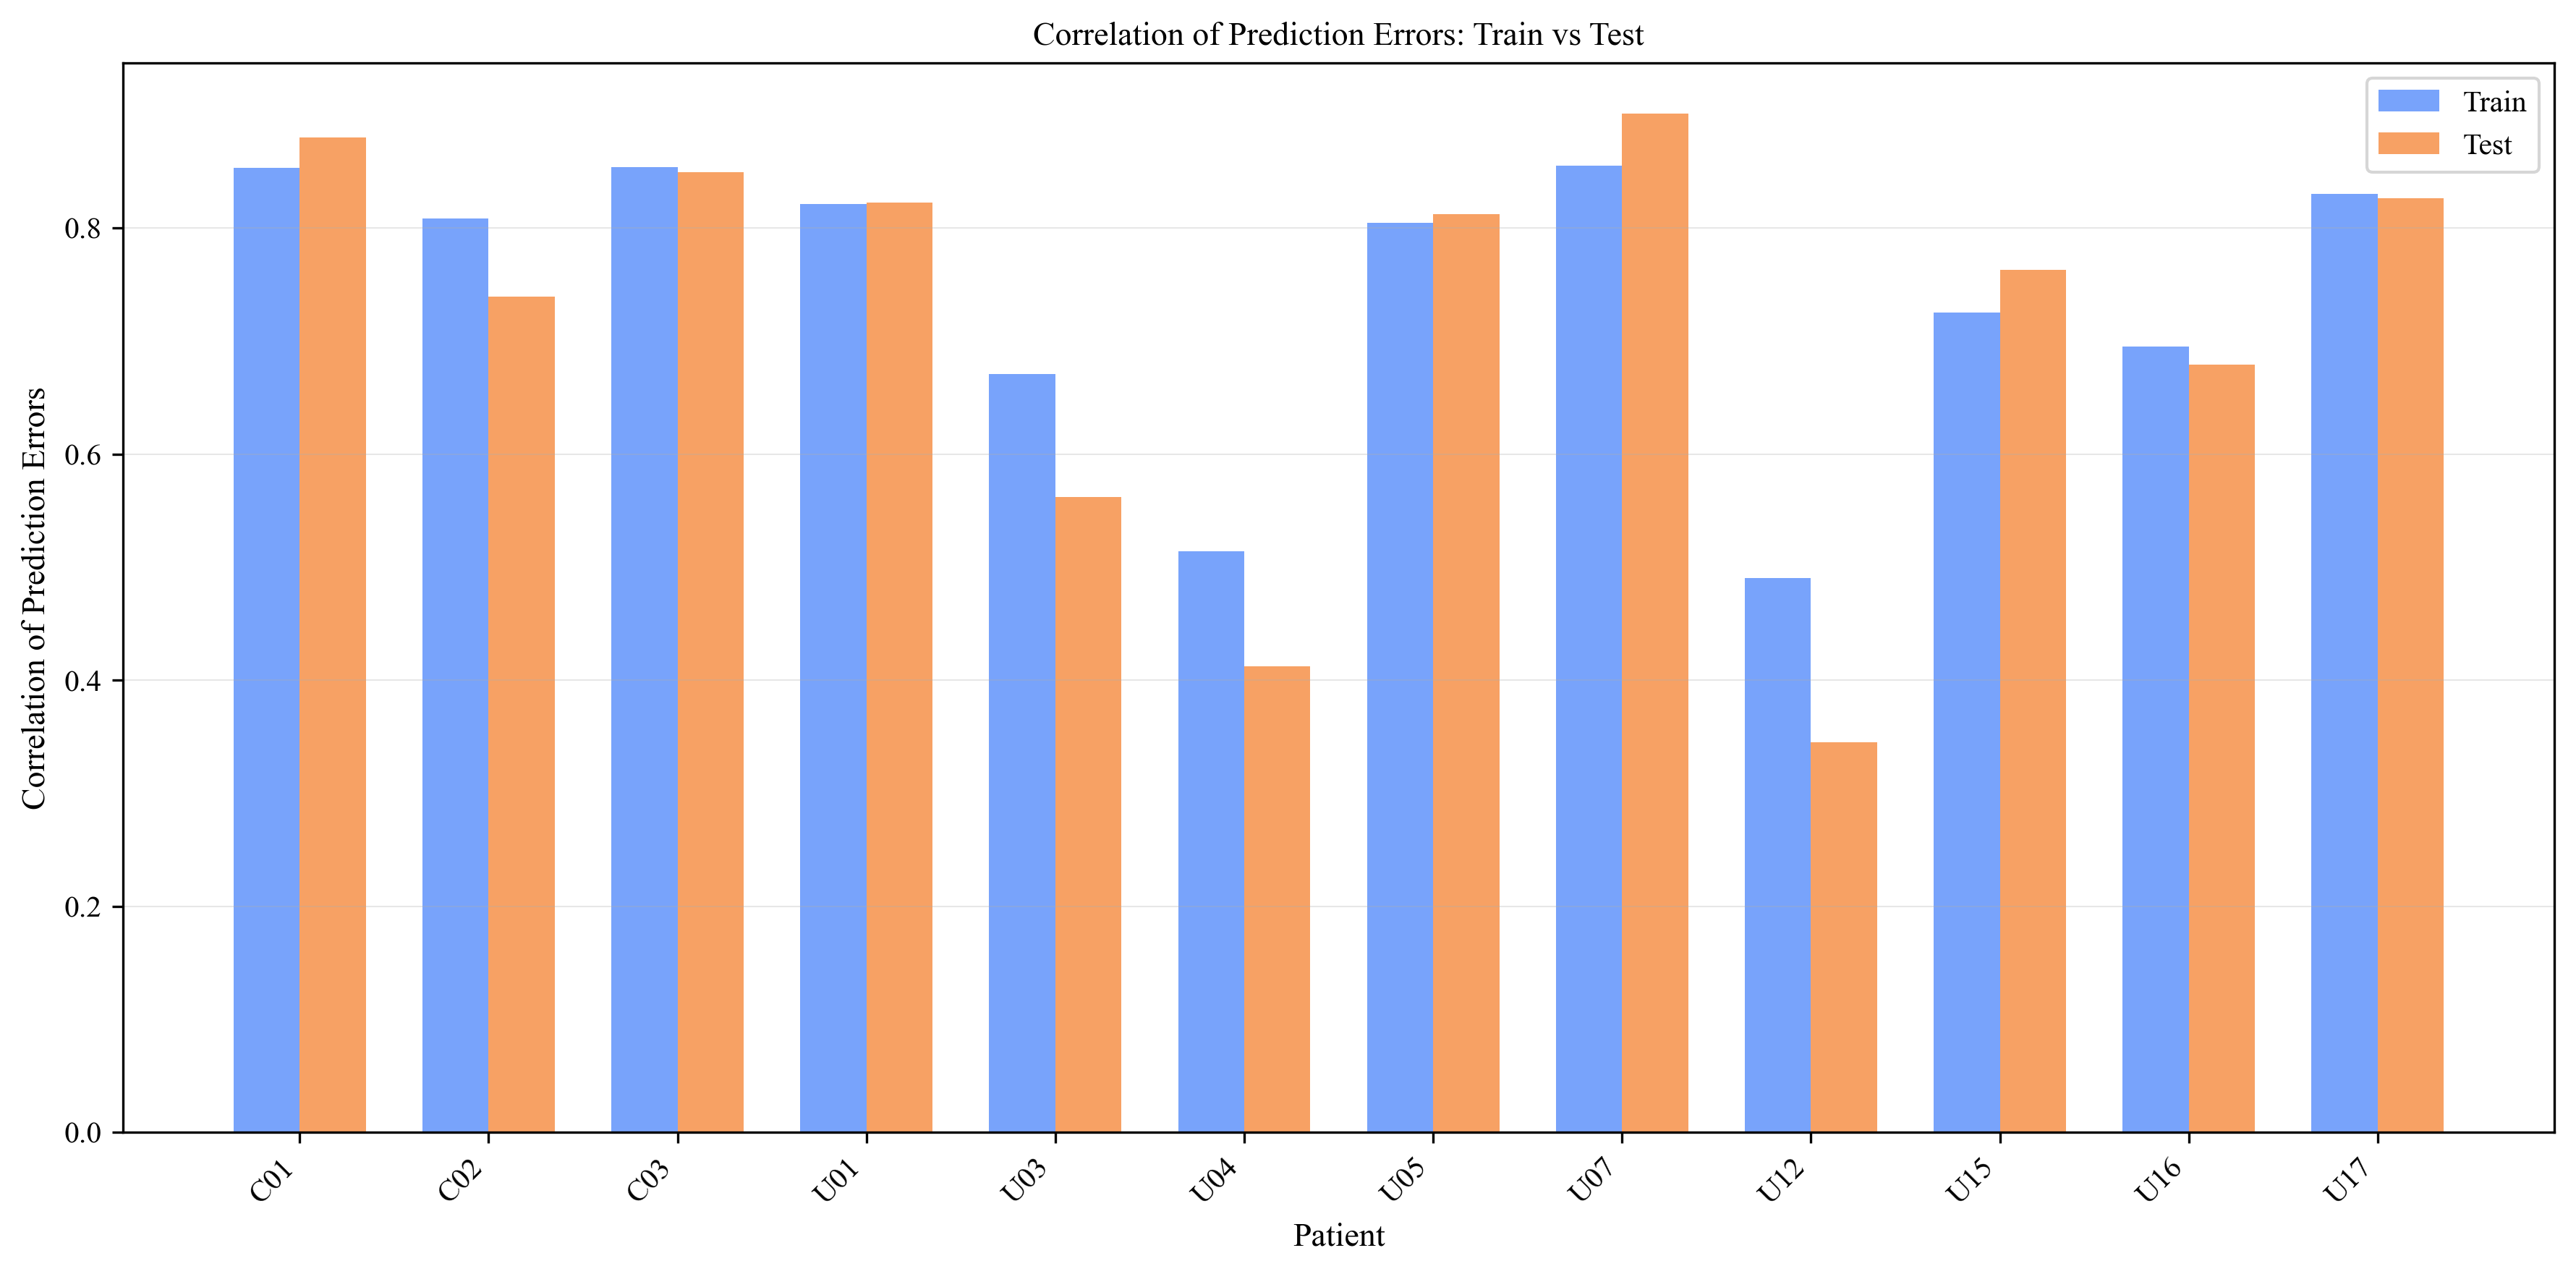

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(t))
width = 0.35

ax.bar([i - width / 2 for i in x], t['train'], width, label='Train', alpha=0.8)
ax.bar([i + width / 2 for i in x], t['test'], width, label='Test', alpha=0.8)

ax.set_xlabel('Patient')
ax.set_ylabel('Correlation of Prediction Errors')
ax.set_title('Correlation of Prediction Errors: Train vs Test')
ax.set_xticks(x)
ax.set_xticklabels(t.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

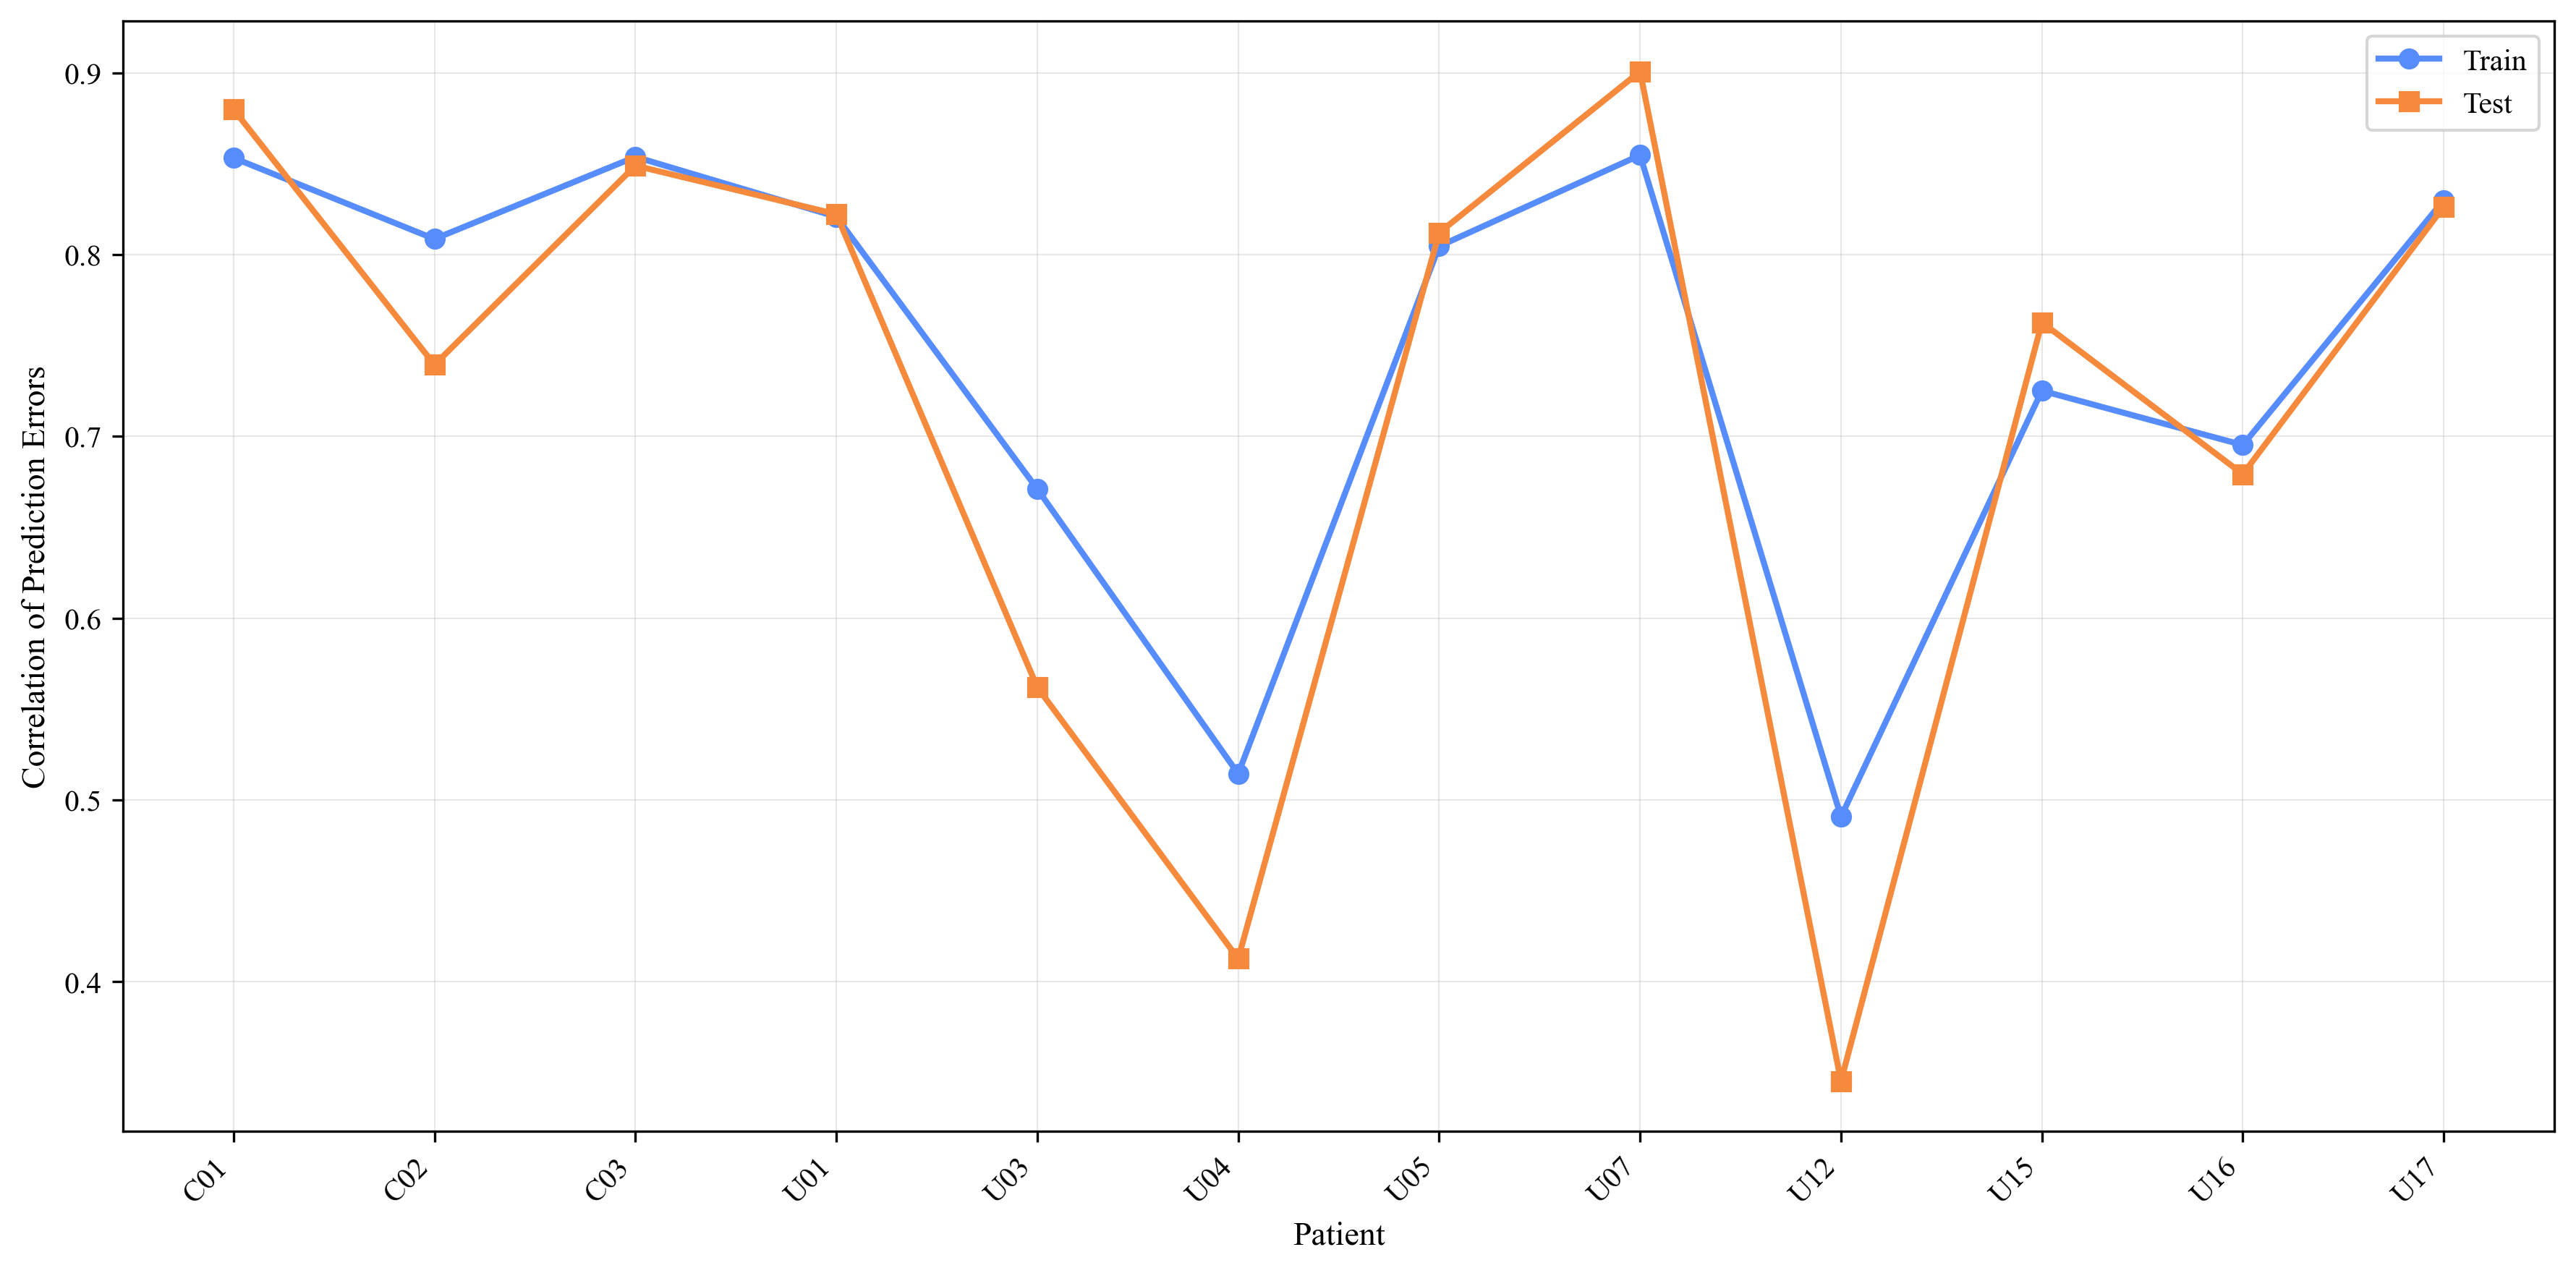

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(t))
ax.plot(x, t['train'], 'o-', label='Train', linewidth=2, markersize=6)
ax.plot(x, t['test'], 's-', label='Test', linewidth=2, markersize=6)

ax.set_xlabel('Patient')
ax.set_ylabel('Correlation of Prediction Errors')
ax.set_xticks(x)
ax.set_xticklabels(t.index, rotation=45, ha='right')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

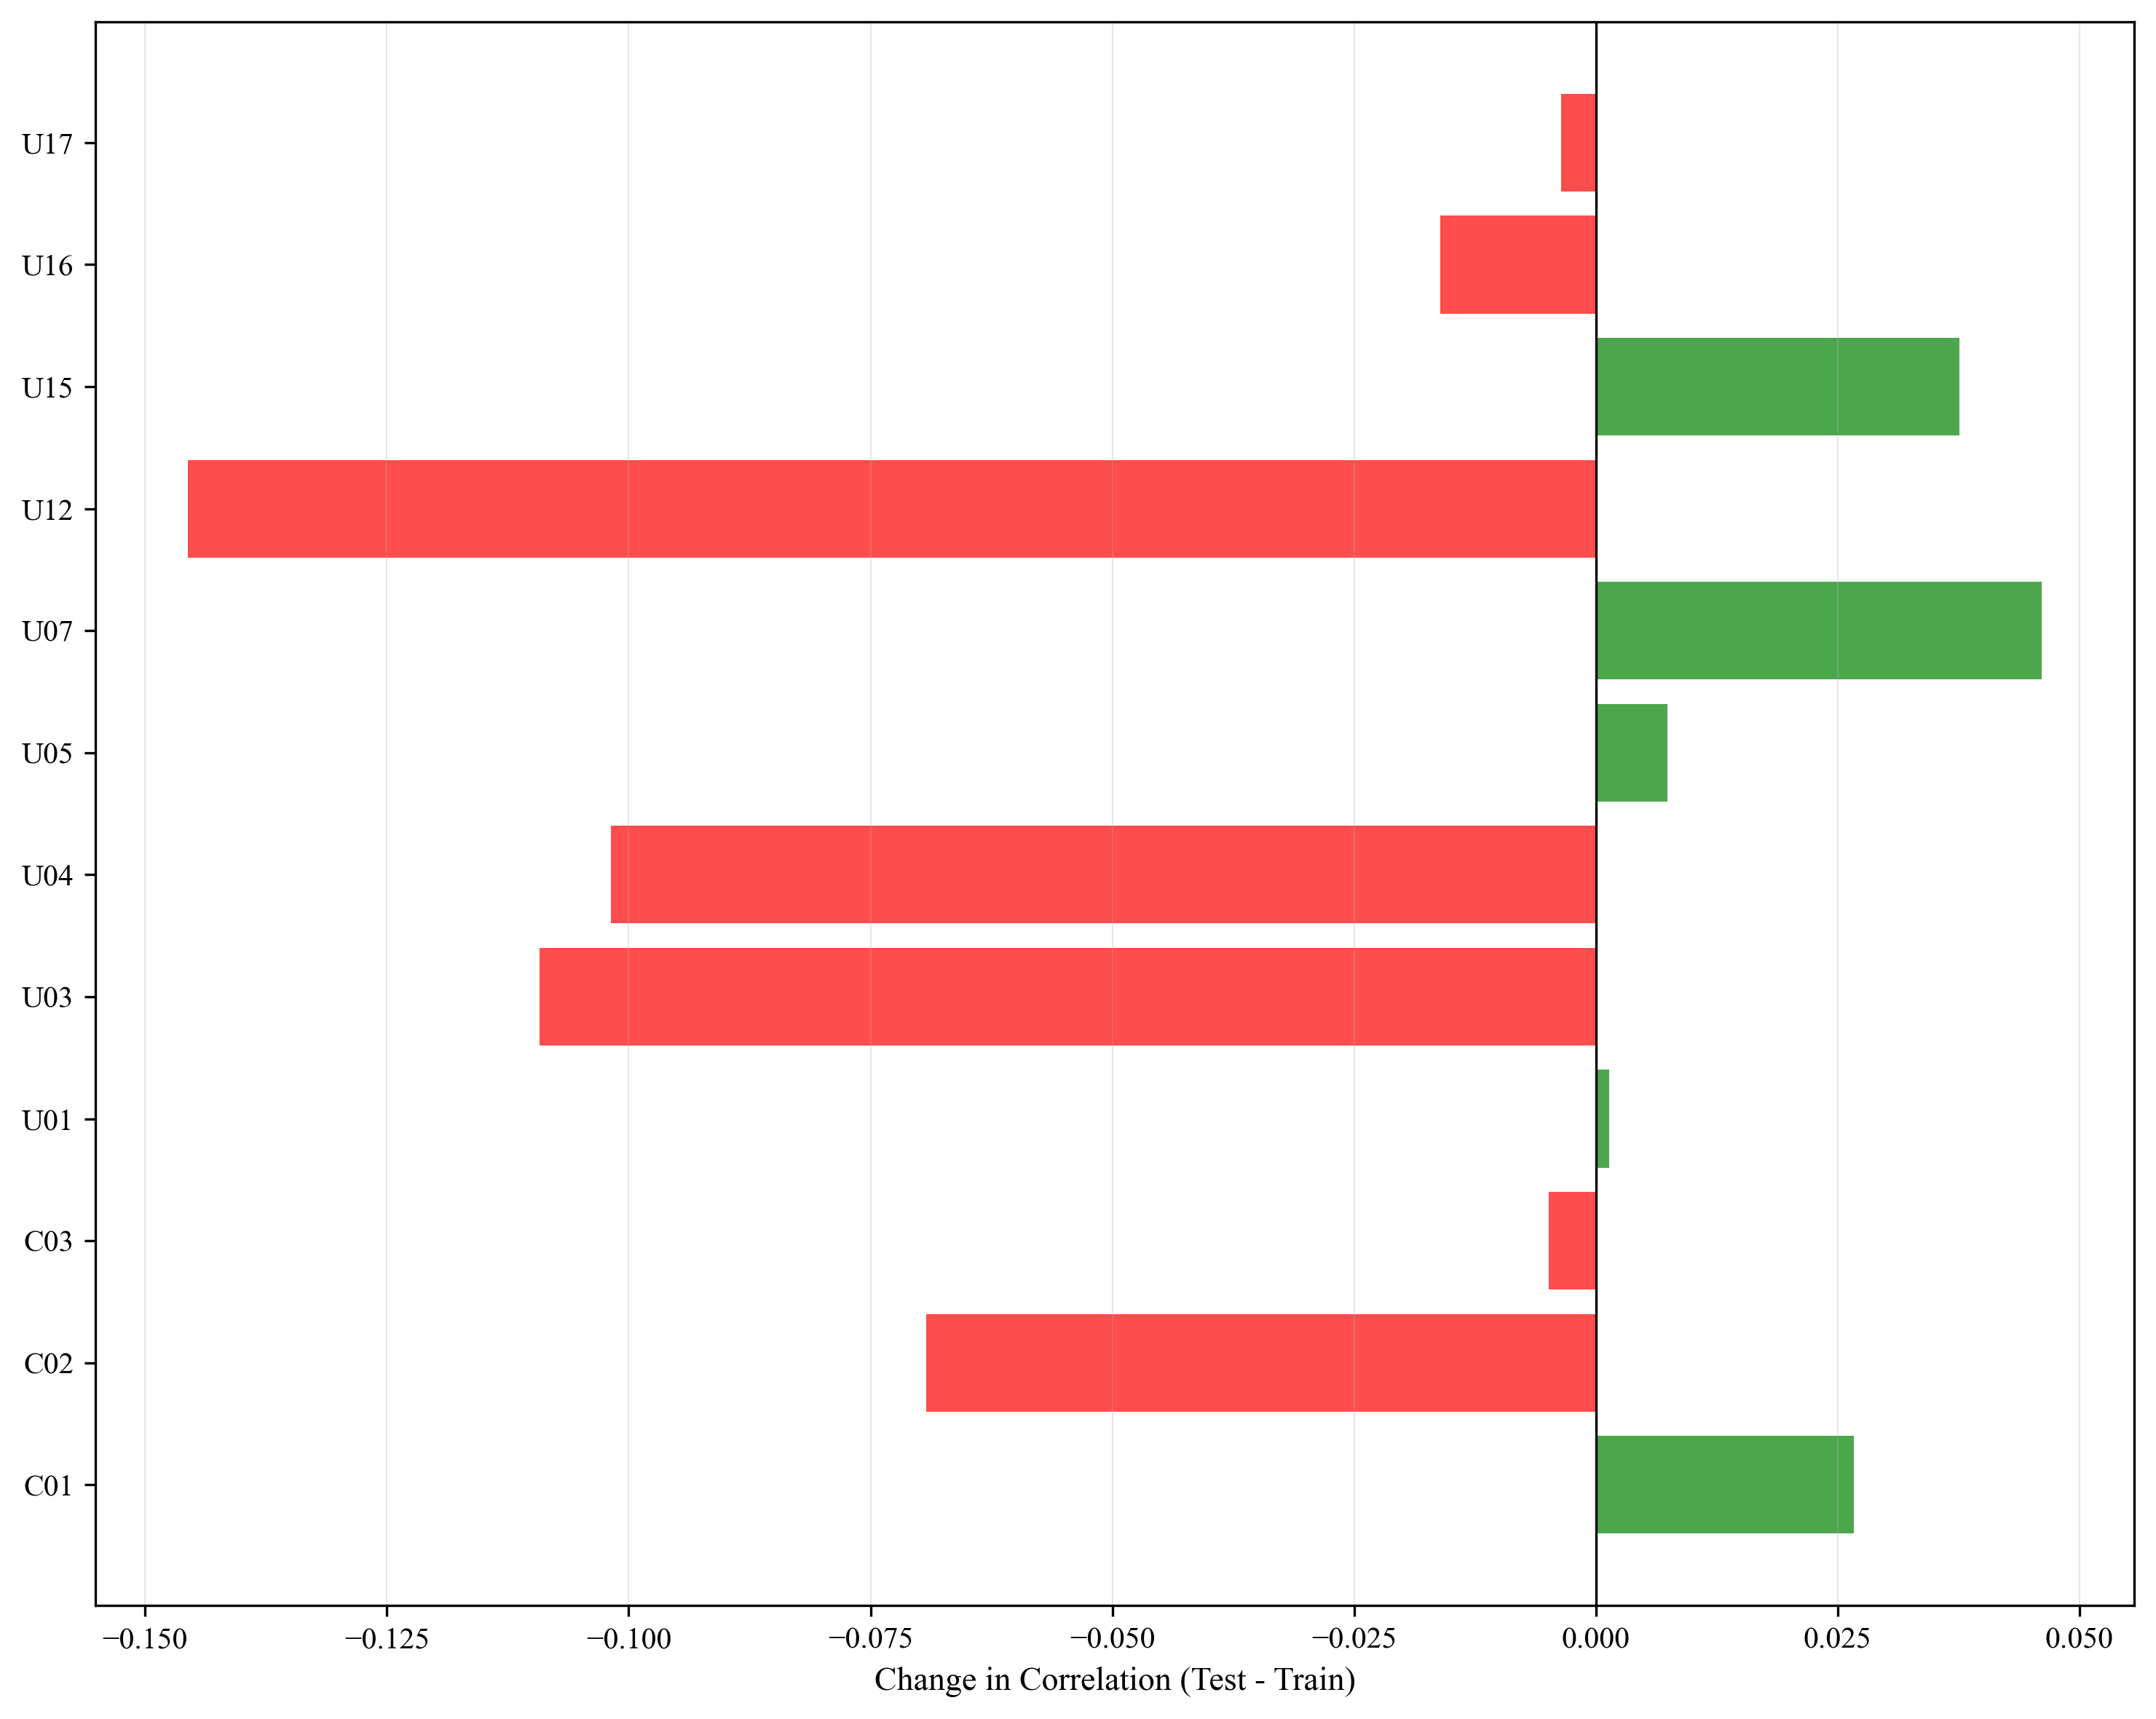

In [12]:
df = t.copy()
df['change'] = df['test'] - df['train']

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['red' if x < 0 else 'green' for x in df['change']]
ax.barh(range(len(df)), df['change'], color=colors, alpha=0.7)

ax.set_yticks(range(len(df)))
ax.set_yticklabels(df.index)
ax.set_xlabel('Change in Correlation (Test - Train)')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

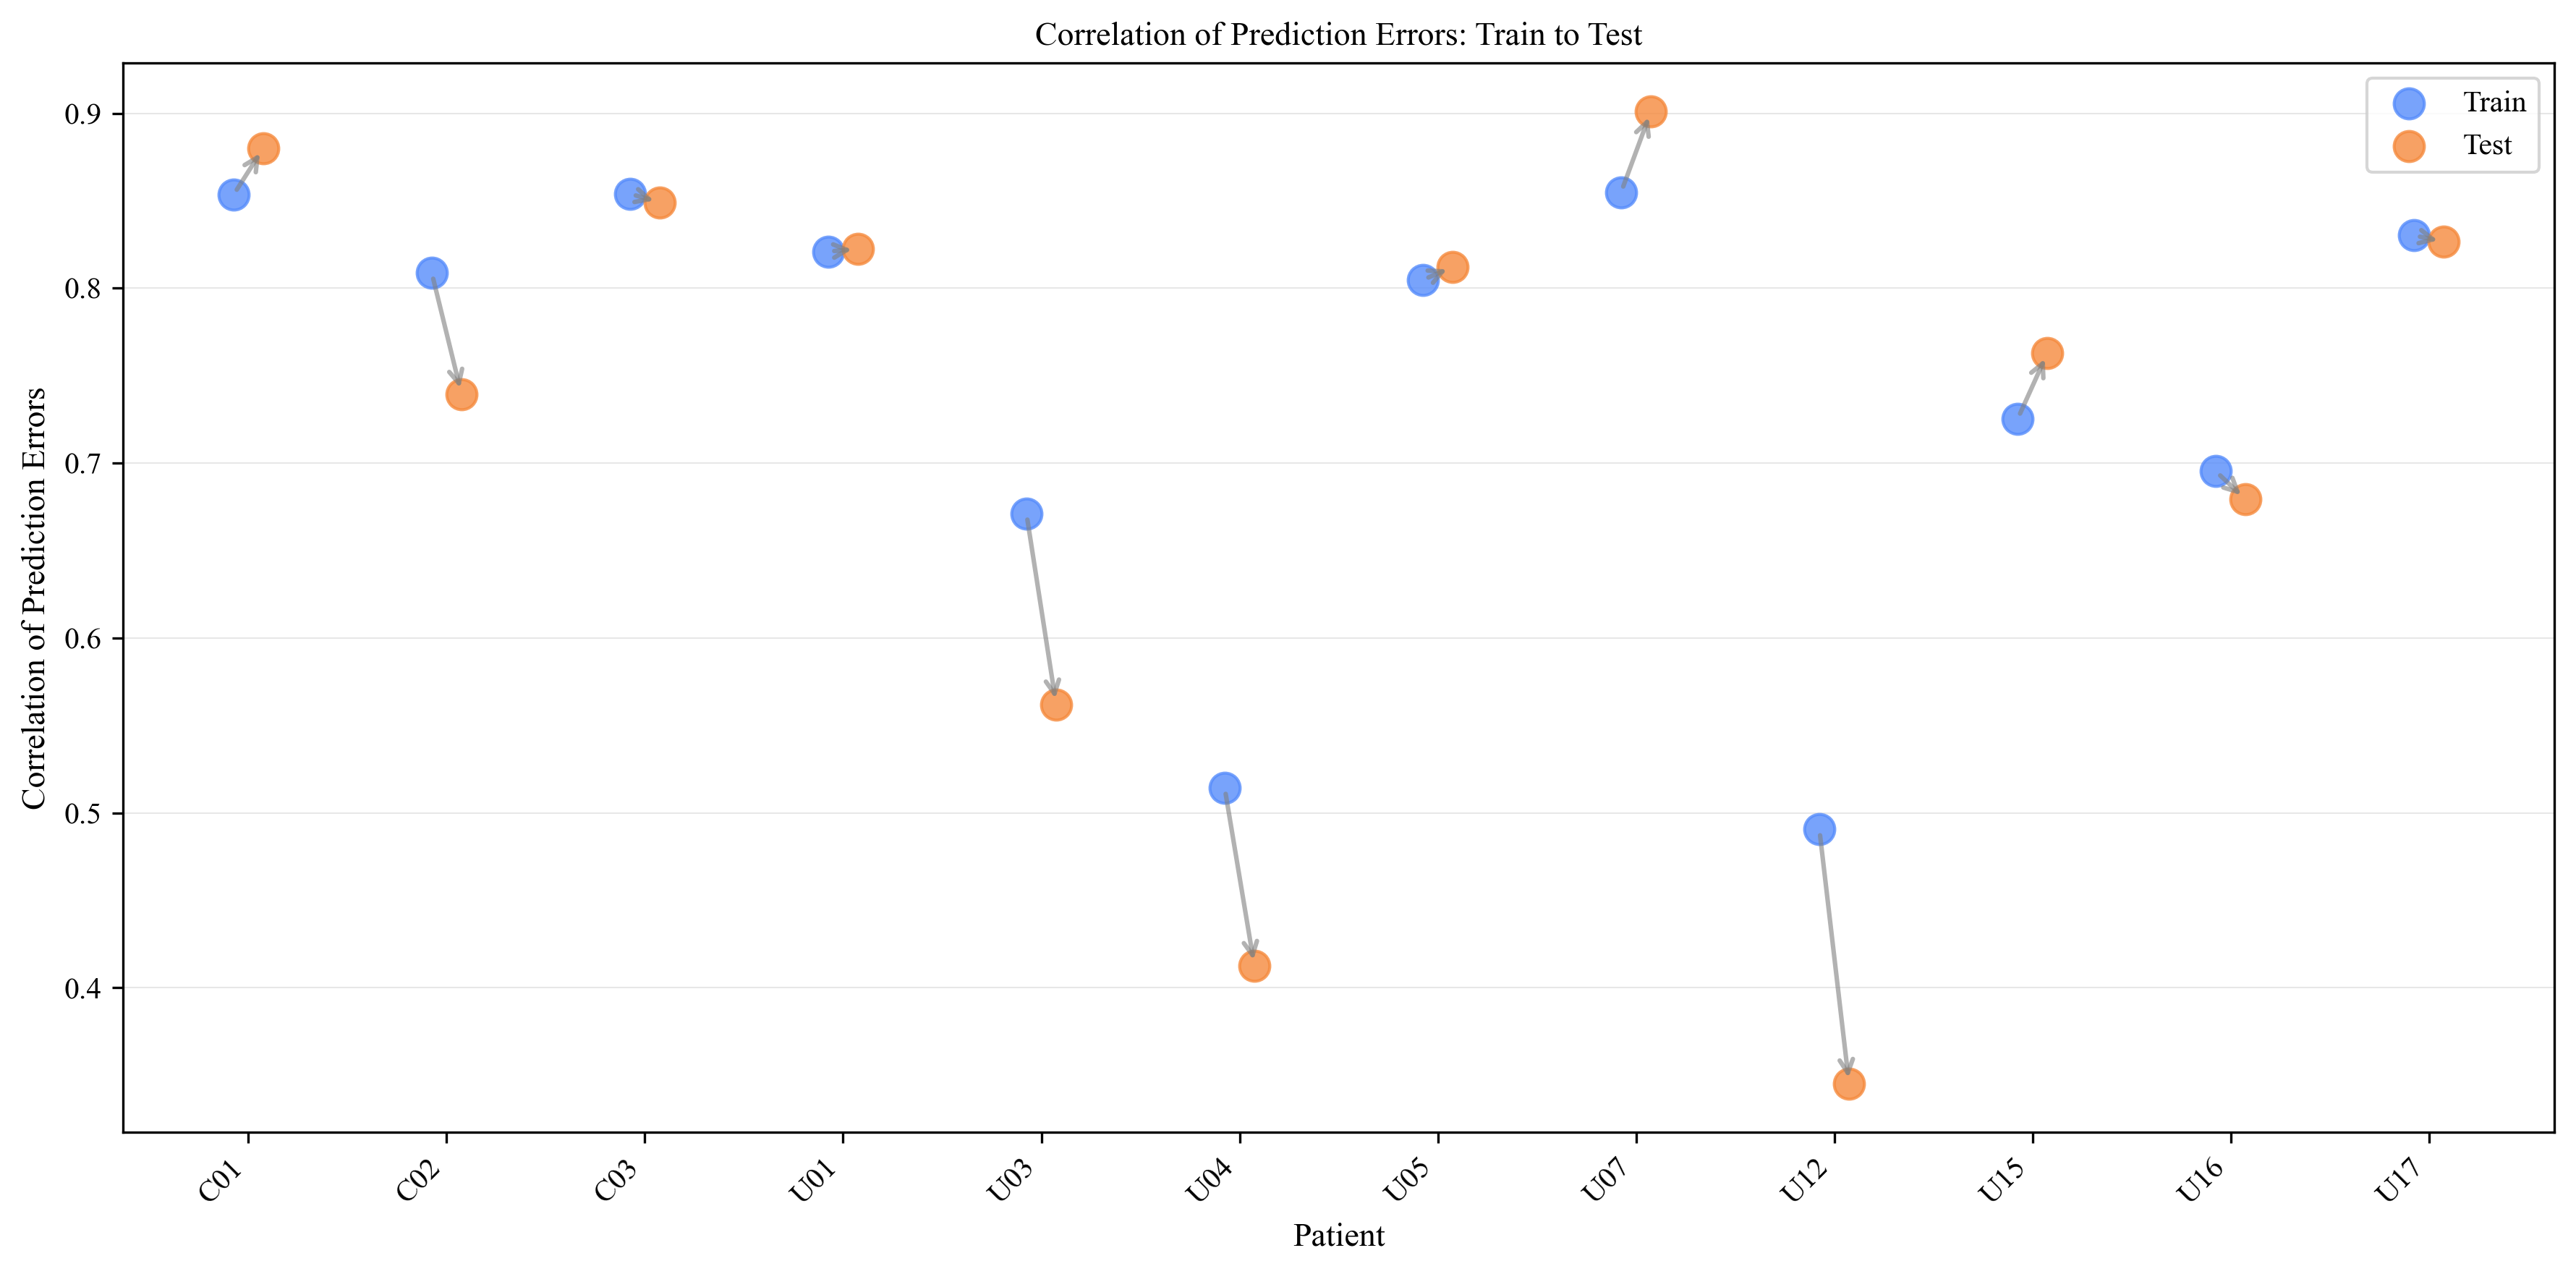

In [13]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(t))
width = 0.15

# Plot scatter points for train and test
ax.scatter(x - width / 2, t['train'], s=100, label='Train', alpha=0.8, zorder=3)
ax.scatter(x + width / 2, t['test'], s=100, label='Test', alpha=0.8, zorder=3)

# Draw arrows from train to test
for i, patient in enumerate(t.index):
    ax.annotate('', xy=(i + width / 2, t.loc[patient, 'test']),
                xytext=(i - width / 2, t.loc[patient, 'train']),
                arrowprops=dict(arrowstyle='->', lw=1.5, alpha=0.6, color='gray'))

ax.set_xlabel('Patient')
ax.set_ylabel('Correlation of Prediction Errors')
ax.set_title('Correlation of Prediction Errors: Train to Test')
ax.set_xticks(x)
ax.set_xticklabels(t.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/p4/zt2tdqw55j53p_57bd3v439w0000gn/T/ipykernel_35853/1270028666.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(patients))


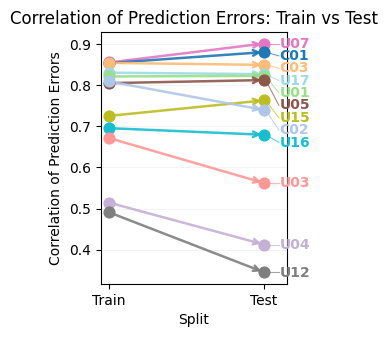

In [34]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# assumes `t` is the DataFrame you already created with columns 'train' and 'test'
patients = list(t.index)

x_train = 0
x_test = 1

cmap = cm.get_cmap('tab20', len(patients))
colors = {p: cmap(i) for i, p in enumerate(patients)}

fig, ax = plt.subplots(figsize=matplotlib_style.latex_figsize(width_fraction=0.5, height_ratio=1.2))

# Sort patients by test value descending (high -> low)
sorted_by_test = sorted(patients, key=lambda p: t.loc[p, 'test'], reverse=True)

# Label placement parameters
label_x = x_test + 0.1  # start just to the right of the Test column
min_sep = 0.03              # minimum vertical separation between labels (data units)
ymin, ymax = ax.get_ylim()
bottom_margin = 0.02 * (ymax - ymin)  # small margin so labels don't get pushed below axis

prev_label_y = None
placed = []  # keep (patient, label_y, color) for drawing

for p in sorted_by_test:
    train_val = t.loc[p, 'train']
    test_val = t.loc[p, 'test']
    color = colors[p]

    ax.annotate(
        '',
        xy=(x_test, test_val),
        xytext=(x_train, train_val),
        arrowprops=dict(arrowstyle='->', color=color, lw=1.8, alpha=0.9),
        zorder=2
    )
    ax.scatter([x_train, x_test], [train_val, test_val], color=color, s=60, zorder=3)



    test_val = t.loc[p, 'test']
    color = colors[p]

    if prev_label_y is None:
        label_y = test_val
    else:
        # keep order: label y cannot be higher than previous (prev_label_y)
        # ensure minimum separation: label_y <= prev_label_y - min_sep
        label_y = min(test_val, prev_label_y - min_sep)

    # clamp so labels don't go below the visible axis (keep them inside visible range)
    min_allowed = ymin + bottom_margin
    if label_y < min_allowed:
        label_y = min_allowed

    placed.append((p, label_y, color))
    prev_label_y = label_y

# Now draw labels (outside axes), and optional thin leader lines from label to marker
for p, label_y, color in placed:
    test_val = t.loc[p, 'test']

    # draw a thin leader line from the test marker to the label (helps readability)
    ax.plot([x_test + 0.01, label_x - 0.005], [test_val, label_y],
            color=color, linewidth=0.8, alpha=0.7, clip_on=False, zorder=2)

    ax.text(label_x, label_y, str(p),
            va='center', ha='left',
            color=color, fontweight='bold',
            clip_on=False)

# x-axis formatting and appearance
ax.set_xticks([x_train, x_test])
ax.set_xticklabels(['Train', 'Test'])
ax.set_ylabel('Correlation of Prediction Errors')
ax.set_xlabel('Split')
ax.set_title('Correlation of Prediction Errors: Train vs Test')
ax.grid(axis='y', alpha=0.2)


plt.tight_layout()
plt.show()

/var/folders/p4/zt2tdqw55j53p_57bd3v439w0000gn/T/ipykernel_35853/3206071609.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20b', len(patients))


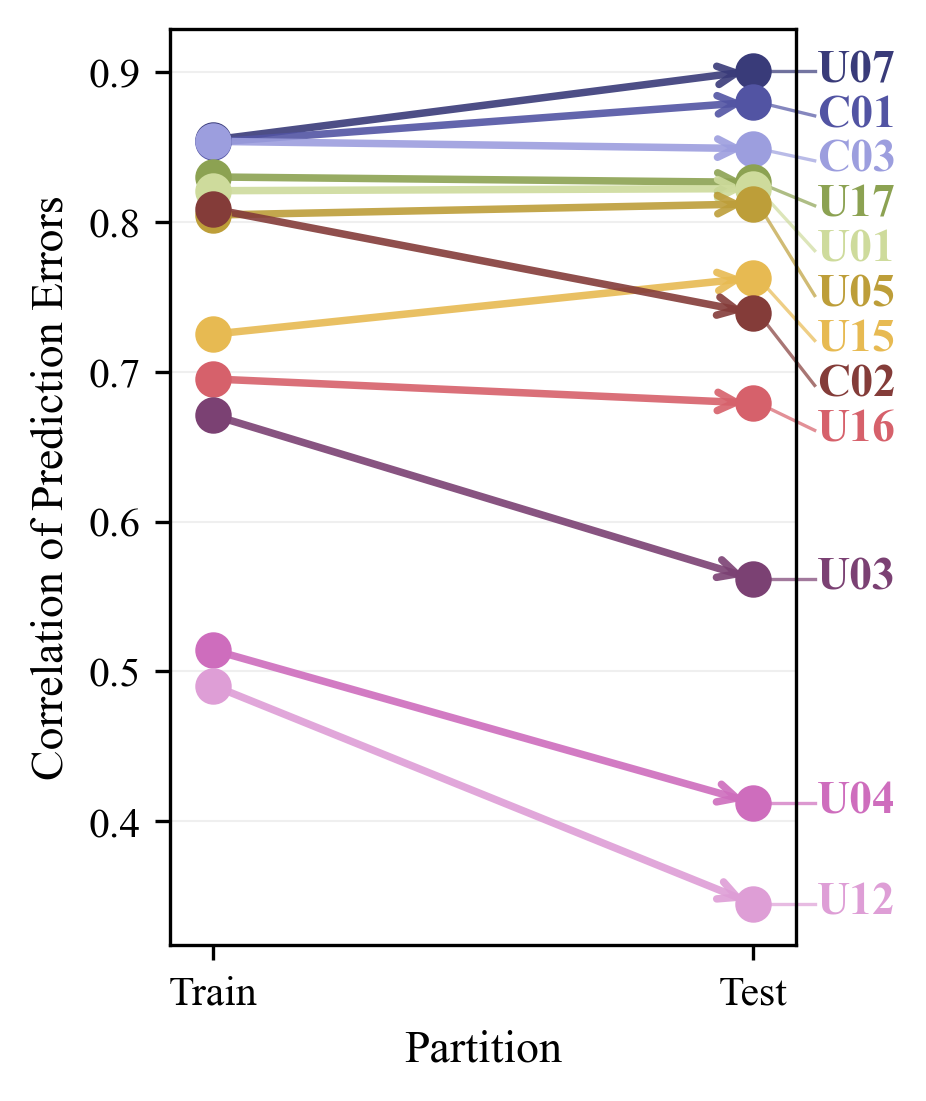

In [60]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

matplotlib_style.apply_style()

# assumes `t` is the DataFrame you already created with columns 'train' and 'test'
patients = list(t.index)

x_train, x_test = 0, 1

cmap = cm.get_cmap('tab20b', len(patients))

fig, ax = plt.subplots(figsize=matplotlib_style.latex_figsize(width_fraction=0.5, height_ratio=1.2))

# Sort patients by test value descending (high -> low)
sorted_by_test = sorted(patients, key=lambda p: t.loc[p, 'test'], reverse=True)

# Label placement parameters
label_x = x_test + 0.12  # start just to the right of the Test column
min_sep = 0.03              # minimum vertical separation between labels (data units)
ymin, ymax = ax.get_ylim()
bottom_margin = 0.02 * (ymax - ymin)  # small margin so labels don't get pushed below axis
min_allowed = ymin + bottom_margin

prev_label_y = None

for i, p in enumerate(sorted_by_test):
    train_val, test_val = t.loc[p, 'train'], t.loc[p, 'test']
    color = cmap(i)

    ax.annotate(
        '',
        xy=(x_test, test_val),
        xytext=(x_train, train_val),
        arrowprops=dict(arrowstyle='->', color=color, lw=1.8, alpha=0.9),
        zorder=2
    )
    ax.scatter([x_train, x_test], [train_val, test_val], color=color, s=60, zorder=3)

    if prev_label_y is None:
        label_y = test_val
    else:
        # keep order: label y cannot be higher than previous (prev_label_y)
        # ensure minimum separation: label_y <= prev_label_y - min_sep
        label_y = min(test_val, prev_label_y - min_sep)

    # clamp so labels don't go below the visible axis (keep them inside visible range)
    if label_y < min_allowed:
        label_y = min_allowed

    prev_label_y = label_y

    # Now draw labels (outside axes), and optional thin leader lines from label to marker
    # draw a thin leader line from the test marker to the label (helps readability)
    ax.plot([x_test + 0.01, label_x - 0.005], [test_val, label_y],
            color=color, linewidth=0.8, alpha=0.7, clip_on=False, zorder=2)

    ax.text(label_x, label_y, str(p),
            va='center', ha='left',
            color=color, fontweight='bold',
            clip_on=False)

# x-axis formatting and appearance
ax.set_xticks([x_train, x_test])
ax.set_xticklabels(['Train', 'Test'])
ax.set_xlabel('Partition')
ax.set_xlim(-0.08, 1.08)

ax.set_ylabel('Correlation of Prediction Errors')

ax.grid(axis='y', alpha=0.2)

plt.tight_layout(pad=0)
plt.show()

In [61]:
fig.savefig(out_path)